In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("data/dataset.csv")

In [16]:
df.head()

,Unnamed: 0,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
0,0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,64.67,0.01,233.75,222.62,232.08,415005.784,1019.784,2030.002,2025-08-01 00:00:00.000
1,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,60.41,0.01,233.68,222.30,230.85,415009.205,1019.784,2030.013,2025-08-01 00:15:00.000
2,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,63.23,0.01,233.48,222.11,230.98,415012.559,1019.784,2030.021,2025-08-01 00:30:00.000
3,3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,65.00,0.01,235.23,222.52,232.00,415015.917,1019.784,2030.033,2025-08-01 00:45:00.000
4,4,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0,62.46,0.01,234.70,222.52,231.78,415019.282,1019.784,2030.043,2025-08-01 01:00:00.000


In [17]:
df.shape

(353949, 19)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 353949 entries, 0 to 353948
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         353949 non-null  int64  
 1   tesisat_no_id      353949 non-null  str    
 2   il                 353949 non-null  str    
 3   ilce               353949 non-null  str    
 4   gerilim_seviyesi   353949 non-null  str    
 5   marka              353949 non-null  str    
 6   model              353949 non-null  str    
 7   abone_grubu        353949 non-null  str    
 8   son_carpan_degeri  353949 non-null  int64  
 9   l1                 353949 non-null  float64
 10  l2                 353949 non-null  float64
 11  l3                 353949 non-null  float64
 12  v1                 278515 non-null  float64
 13  v2                 278515 non-null  float64
 14  v3                 278515 non-null  float64
 15  t0                 353949 non-null  float64
 16  ri           

In [19]:
df.isnull().sum()

Unnamed: 0               0
tesisat_no_id            0
il                       0
ilce                     0
gerilim_seviyesi         0
marka                    0
model                    0
abone_grubu              0
son_carpan_degeri        0
l1                       0
l2                       0
l3                       0
v1                   75434
v2                   75434
v3                   75434
t0                       0
ri                   10240
rc                   10240
load_profile_date        0
dtype: int64

In [20]:
# Enterpolasyon (Zaman serisi için en sağlıklı doldurma)
df['v1'] = df['v1'].interpolate()
df['v2'] = df['v2'].interpolate()
df['v3'] = df['v3'].interpolate()

# Hata aldığın satırın yeni ve güncel hali:
df = df.ffill()

In [21]:
df["load_profile_date"] = pd.to_datetime(df["load_profile_date"])
df.dtypes

Unnamed: 0                    int64
tesisat_no_id                   str
il                              str
ilce                            str
gerilim_seviyesi                str
marka                           str
model                           str
abone_grubu                     str
son_carpan_degeri             int64
l1                          float64
l2                          float64
l3                          float64
v1                          float64
v2                          float64
v3                          float64
t0                          float64
ri                          float64
rc                          float64
load_profile_date    datetime64[us]
dtype: object

In [22]:
df = df.sort_values(["tesisat_no_id","load_profile_date"])

df["tuketim"] = df.groupby("tesisat_no_id")["t0"].diff()


df[["t0","tuketim"]].head(10)

,t0,tuketim
7263,3868.324,NaN
7264,3868.324,0.000
7265,3868.325,0.001
7266,3868.325,0.000
7267,3868.326,0.001
7268,3868.326,0.000
7269,3868.326,0.000
7270,3868.326,0.000
7271,3868.326,0.000
7272,3868.327,0.001


In [23]:
df = df[df["tuketim"] >= 0]

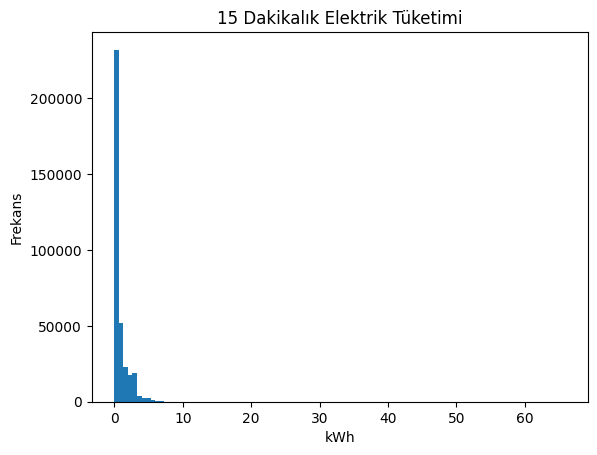

In [24]:
plt.hist(df["tuketim"], bins=100)

plt.title("15 Dakikalık Elektrik Tüketimi")
plt.xlabel("kWh")
plt.ylabel("Frekans")

plt.show()

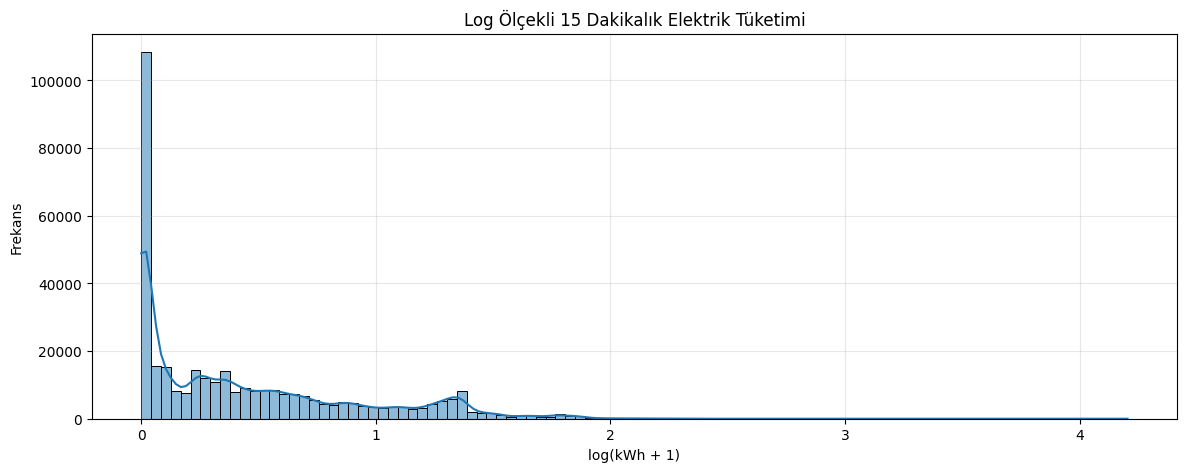

In [25]:
import numpy as np

plt.figure(figsize=(14,5))

sns.histplot(np.log1p(df["tuketim"]), bins=100, kde=True)

plt.title("Log Ölçekli 15 Dakikalık Elektrik Tüketimi")
plt.xlabel("log(kWh + 1)")
plt.ylabel("Frekans")

plt.grid(alpha=0.3)

plt.show()

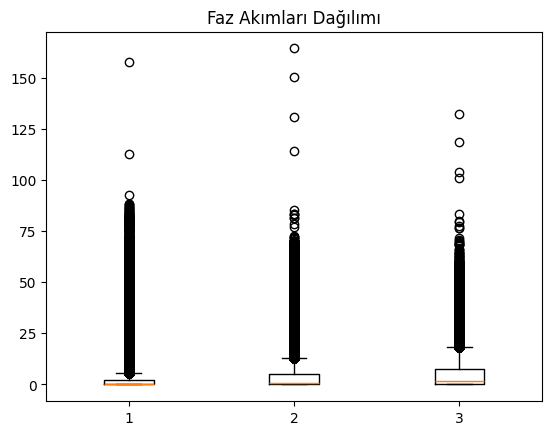

In [26]:
plt.boxplot([df["l1"], df["l2"], df["l3"]])

plt.title("Faz Akımları Dağılımı")
plt.show()

In [27]:
il_tuketim = df.groupby("il")["tuketim"].mean()

il_tuketim

il
AMASYA    0.840546
ORDU      2.166642
SAMSUN    0.815381
SİNOP     1.213498
ÇORUM     0.534064
Name: tuketim, dtype: float64

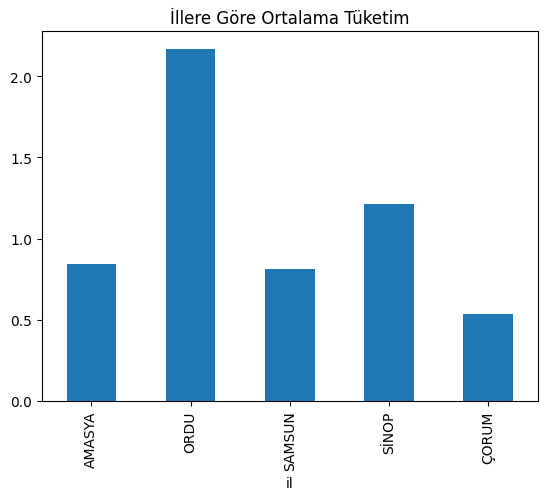

In [28]:
il_tuketim.plot(kind="bar")

plt.title("İllere Göre Ortalama Tüketim")

plt.show()

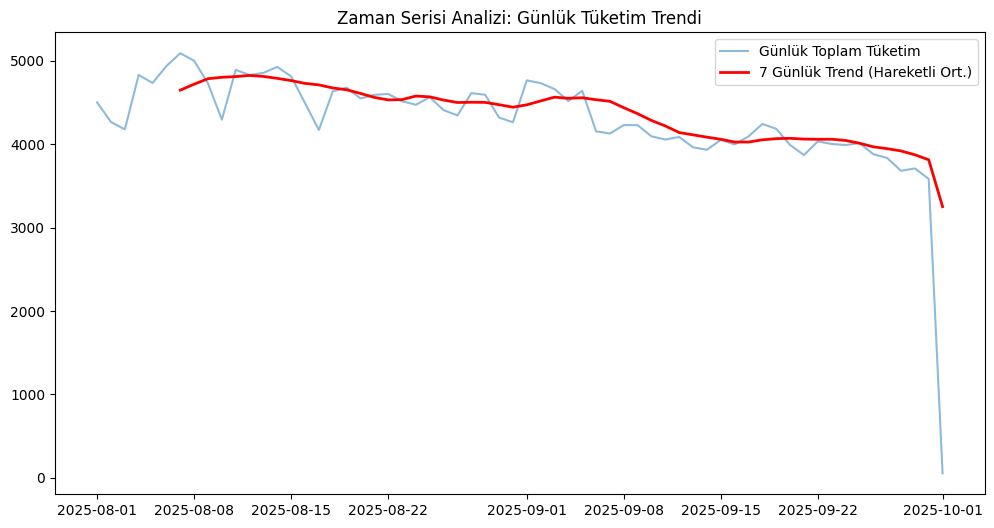

In [32]:
df['load_profile_date'] = pd.to_datetime(df['load_profile_date'])

df_temp = df.set_index('load_profile_date')

gunluk_tuketim = df_temp['tuketim'].resample('D').sum()

yedi_gunluk_ortalama = gunluk_tuketim.rolling(window=7).mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(gunluk_tuketim, label='Günlük Toplam Tüketim', alpha=0.5)
plt.plot(yedi_gunluk_ortalama, label='7 Günlük Trend (Hareketli Ort.)', color='red', linewidth=2)
plt.title("Zaman Serisi Analizi: Günlük Tüketim Trendi")
plt.legend()
plt.show()

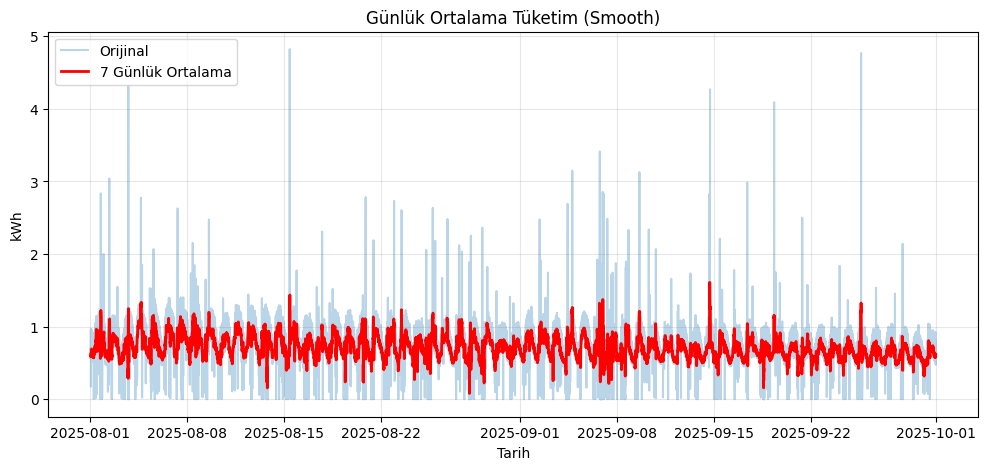

In [30]:
# Günlük ortalama tüketimi hesapla (kod 1'deki adım)
gunluk = df.groupby("load_profile_date")["tuketim"].mean()

# 7 günlük hareketli ortalama (kod 2'nin ek adımı)
gunluk_smooth = gunluk.rolling(window=7, center=True).mean()

# Grafik çizimi
plt.figure(figsize=(12, 5))
plt.plot(gunluk, alpha=0.3, label="Orijinal")
plt.plot(gunluk_smooth, color='red', linewidth=2, label="7 Günlük Ortalama")
plt.title("Günlük Ortalama Tüketim (Smooth)")
plt.xlabel("Tarih")
plt.ylabel("kWh")
plt.legend()
plt.grid(alpha=0.3)
plt.show()